In [2]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.4 MB/s eta 0:00:00


In [125]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.1 MB/s eta 0:00:00


In [126]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\langle {2} \rangle$.

 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

##Exercise 1:

Suponiendo el estado inicial

$$t = 0 , \langle 2 \rangle = c(0) = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

Entonces

$$ c(t) = U(t)c(0) = \begin{pmatrix} U_{11} & U_{12} \\ U_{21} & U_{22}\end{pmatrix} \begin{pmatrix} 0 \\ 1 \end{pmatrix} = \begin{pmatrix} U_{12}(t) \\ U_{22}(t)\end{pmatrix}$$

La probabilidad de ocupacion es

$$P_i(t) = |c_i(t)|^2 = |U_{i2}(t)|^2$$

Se define $U_{22}(t)$ como

$$ U_{22}(t) = cos(\frac{|c|t}{ħ}) + isin(\frac{|c|t}{ħ})\frac{c_z}{|c|}$$

Definiendo

$$Ω = \frac{c}{ħ} = \sqrt{|Ω_R|^2 + Δ^2} \\ Ω_R = \frac{c_x + ic_y}{ħ} \\ Δ = \frac{c_z}{ħ} $$

Reescribiendo en la probabilidad de ocupacion

$$P_2(t) = cos^2(Ωt) + sin^2(Ωt)\frac{Δ^2}{Ω^2}$$

Suponiendo el detuning como $\frac{Ω_R}{2}$, entonces

$$P_2(t) = cos^2(\frac{\sqrt{5}}{2}|Ω_R|t) + \frac{1}{5}sin^2(\frac{\sqrt{5}}{2}|Ω_R|t) \\ Ω =\frac{\sqrt{5}}{2}|Ω_R| \\ \frac{Δ^2}{Ω^2} = \frac{1}{5}$$

Finalmente se tiene $\frac{Ω}{2π} ≈ 24.79 GHz $.

- spin-flitting:

$$P(t) = \frac{\Omega_R^2}{\Omega^2}sin^2(\frac{\Omega}{2}t)$$

In [127]:
#Parametros
Omega_R = 24.79e9* 2*np.pi
Omega_eff = (np.sqrt(5)/2)*Omega_R

print(f"Omega = {Omega_R*1e-9} GHz")
print(f"Omega_R = {Omega_eff*1e-9} GHz")

Omega = 155.76016376498194 GHz
Omega_R = 174.14515718249962 GHz


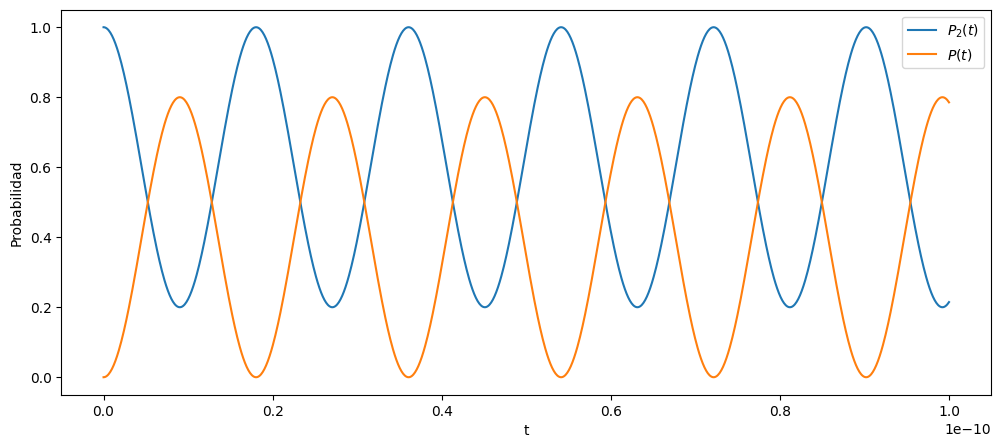

In [128]:
#Probabilidad
def P2(omega,t):
  return np.cos(omega*t)**2 + (1/5)*np.sin(omega*t)**2

def P(omega,t):
  return (4/5)*np.sin(omega*t)**2

t = np.linspace(0,100e-12,1000)

plt.figure(figsize=(12,5))


plt.plot(t,P2(Omega_eff,t),label = r'$P_2(t)$')
plt.plot(t,P(Omega_eff,t),label = r'$P(t)$')
plt.xlabel('t')
plt.ylabel('Probabilidad')

plt.legend()
plt.show()

##Exercise 2:

In [129]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
simulator = AerSimulator()

Estado de bell: dos qubits

In [140]:
qc = QuantumCircuit(2)
qc.x(0)
qc.barrier()
qc.h(0)
qc.cx(0,1)
qc.measure_all()
qc.draw()

┌───┐ ░ ┌───┐      ░ ┌─┐   
   q_0: ┤ X ├─░─┤ H ├──■───░─┤M├───
        └───┘ ░ └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ──────░──────┤ X ├─░──╫─┤M├
              ░      └───┘ ░  ║ └╥┘
meas: 2/══════════════════════╩══╩═
                              0  1

{'00': 517, '11': 507}


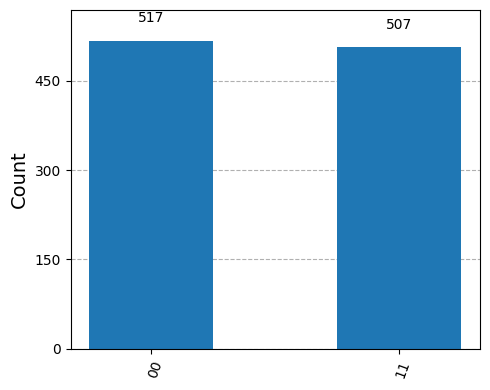

In [141]:
count = simulator.run(qc).result().get_counts()
print(count)
plot_histogram(count,figsize=(5,4))

Estado de bell:3 qubits

In [144]:
qc1 = QuantumCircuit(3)
qc1.x(0)
qc1.barrier()
qc1.h(0)
qc1.cx(0,1)
qc1.cx(1,2)
qc1.measure_all()
qc1.draw()

┌───┐ ░ ┌───┐           ░ ┌─┐      
   q_0: ┤ X ├─░─┤ H ├──■────────░─┤M├──────
        └───┘ ░ └───┘┌─┴─┐      ░ └╥┘┌─┐   
   q_1: ──────░──────┤ X ├──■───░──╫─┤M├───
              ░      └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────░───────────┤ X ├─░──╫──╫─┤M├
              ░           └───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════════════╩══╩══╩═
                                   0  1  2

{'000': 516, '111': 508}


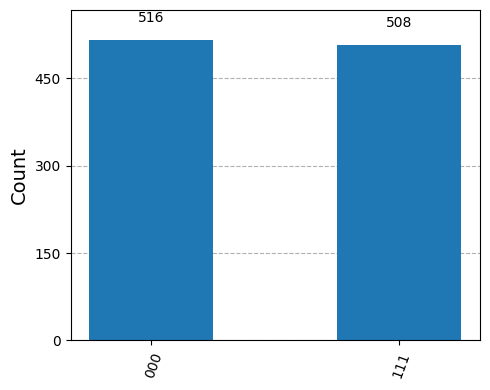

In [145]:
count1 = simulator.run(qc1).result().get_counts()
print(count1)
plot_histogram(count1,figsize=(5,4))

estado de bell: adicion compuerta x

In [146]:
qc2 = QuantumCircuit(3)
qc2.x(0)
qc2.barrier()
qc2.h(0)
qc2.cx(0,1)
qc2.cx(1,2)
qc2.barrier()
qc2.x(1)

qc2.measure_all()
qc2.draw()

┌───┐ ░ ┌───┐           ░       ░ ┌─┐      
   q_0: ┤ X ├─░─┤ H ├──■────────░───────░─┤M├──────
        └───┘ ░ └───┘┌─┴─┐      ░ ┌───┐ ░ └╥┘┌─┐   
   q_1: ──────░──────┤ X ├──■───░─┤ X ├─░──╫─┤M├───
              ░      └───┘┌─┴─┐ ░ └───┘ ░  ║ └╥┘┌─┐
   q_2: ──────░───────────┤ X ├─░───────░──╫──╫─┤M├
              ░           └───┘ ░       ░  ║  ║ └╥┘
meas: 3/═══════════════════════════════════╩══╩══╩═
                                           0  1  2

{'000': 516, '111': 508}


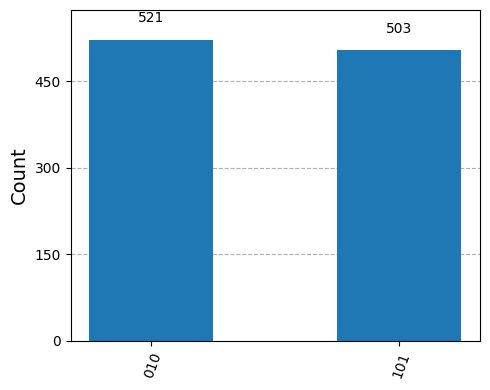

In [147]:
count2 = simulator.run(qc2).result().get_counts()
print(count1)
plot_histogram(count2,figsize=(5,4))

Los tres qbits estan entrelazados pero los estados calculados ahora son $010$ y $101$